# Weak-constraint 4DVar on Lorenz-63

Same as strong-4DVar, but the dynamics are no longer a hard
constraint. The control is augmented with a per-step model-error
trajectory $\{\eta_t\}_{t=1}^{T}$:

$$
x_t = M(x_{t-1}) + \eta_t, \qquad \eta_t \sim \mathcal{N}(0, Q).
$$

Cost gains a model-error term
$\tfrac{1}{2}\sum_t \|\eta_t\|^2_{Q^{-1}}$. With $Q = B$ (the same
variance as the background), the result trades some fit to the
dynamics for additional flexibility — useful when the forward model
is imperfect, but a small handicap for the *perfect*-model Lorenz
benchmark used here.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import lineax as lx
import matplotlib.pyplot as plt
import vardax as vdx

from assimilation import generate_problem, run_method, Lorenz63Forward

## 1. Shared problem

In [2]:
prob = generate_problem(key=jax.random.PRNGKey(42))
batch = vdx.Batch1D(input=prob.obs[None], mask=prob.mask[None], target=None)
fwd = Lorenz63Forward(dt=prob.dt)

## 2. Build Weak-4DVar

Note the additional `model_err_cov_op` argument. Here we reuse
`B_op_state` as $Q$ — generous, in the sense that we believe model
error could be as big as the background error.

In [3]:
H_state = lx.IdentityLinearOperator(jax.ShapeDtypeStruct((3,), jnp.float32))
weak = vdx.WeakFourDVar(
    forward=fwd,
    obs_op=vdx.LinearObs(H_mat=H_state),
    prior_mean=prob.prior_mean_state,
    prior_cov_op=prob.B_op_state,
    obs_cov_op=prob.R_op_state,
    model_err_cov_op=prob.B_op_state,
)

## 3. Run + reconstruct trajectory

Weak-4DVar returns `(x_0_star, etas)` where the etas are the
per-step model-error vectors. We rebuild the trajectory via the
perturbed forward.

In [4]:
def weak_run():
    x0_b, etas_b = weak(batch)
    x0, etas = x0_b[0], etas_b[0]
    def step(s, eta):
        new = fwd.step(s, fwd.dt) + eta
        return new, new
    _, traj = jax.lax.scan(step, x0, etas)
    return jnp.concatenate([x0[None, :], traj], axis=0)


result = run_method("weak_4dvar", weak_run, prob)
print(f"Weak-4DVar RMSE (total):       {result.rmse_total:.3f}")
print(f"Weak-4DVar RMSE per component: x={result.rmse_per_component[0]:.3f}  "
      f"y={result.rmse_per_component[1]:.3f}  z={result.rmse_per_component[2]:.3f}")
print(f"Weak-4DVar runtime:            {result.runtime_ms:.1f} ms")

Weak-4DVar RMSE (total):       7.147
Weak-4DVar RMSE per component: x=0.689  y=4.668  z=11.444
Weak-4DVar runtime:            2510.7 ms


## 4. Visualise

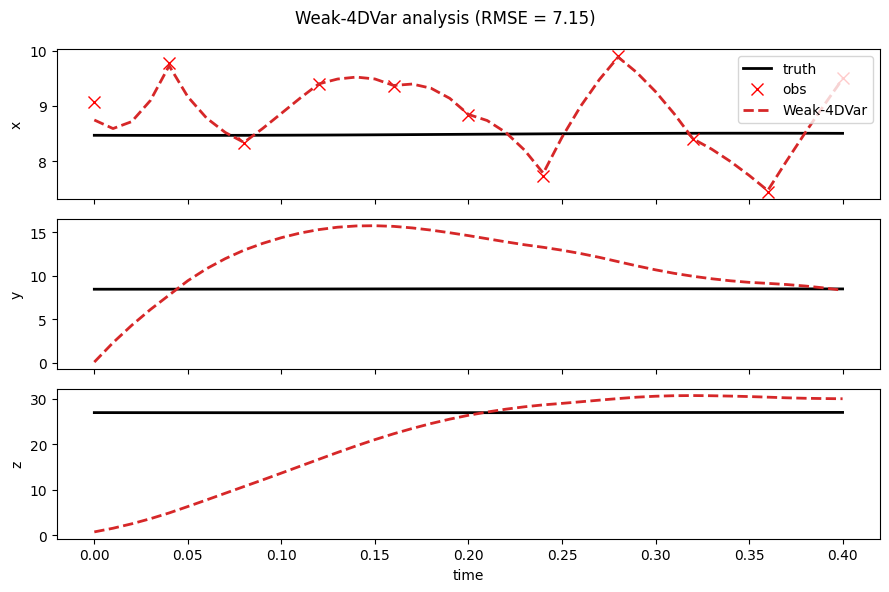

In [5]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
t = jnp.arange(prob.T_plus_1) * prob.dt
for i, ax in enumerate(axs):
    ax.plot(t, prob.truth[:, i], "k-", lw=2, label="truth")
    obs_t = t[prob.mask[:, i] > 0.5]
    if len(obs_t) > 0:
        ax.plot(obs_t, prob.obs[prob.mask[:, i] > 0.5, i], "rx", ms=8, label="obs")
    ax.plot(t, result.mean[:, i], "C3--", lw=2, label="Weak-4DVar")
    ax.set_ylabel("xyz"[i])
    if i == 0:
        ax.legend(loc="upper right")
axs[-1].set_xlabel("time")
fig.suptitle(f"Weak-4DVar analysis (RMSE = {result.rmse_total:.2f})")
fig.tight_layout()
plt.show()

## 5. Discussion

Weak-4DVar trades a higher RMSE for protection against model error.
On the *perfect*-model Lorenz benchmark this is a handicap — the
perfect-model assumption is true, so strong-4DVar wins. In an
operational setting where the forward model is approximate
(e.g., coarsely-resolved fluid dynamics, neglected sub-grid
processes), the same setup gives strong-4DVar a falsely-confident
answer and weak-4DVar a calibrated one.

The extra control degrees of freedom also make the inner solve
substantially more expensive — see the runtime column in the
comparison notebook.